# Parte 2: Escalonamento por meio da Normalização nas variáveis quantitativas

## 2.1. Definição do Tipo de Escalonamento para as Variáveis Quantitativas

### Introdução
No contexto do desenvolvimento de modelos preditivos, a etapa de pré-processamento de dados é fundamental para a performance e a confiabilidade do resultado final de um modelo. Conforme é documentado na literatura de ciência de dados, a grande maioria dos algoritmos de aprendizado de máquina não interpreta o significado semântico das variáveis, tratando-as apenas como valores numéricos (MÜLLER; GUIDO, 2017).  

Dentro deste processo, o escalonamento de variáveis quantitativas é considerada como uma técnica indispensável, cuja omissão pode introduzir vieses e levar a conclusões equivocadas. Algoritmos que se baseiam em medidas de distância, como o **K-Nearest Neighbors (KNN)**, ou que utilizam métodos de otimização por gradiente descendente, como a **regressão logística** e as **redes neurais**, são particularmente sensíveis às magnitudes das variáveis de entrada.  

A existência de escalas diferentes entre os atributos — por exemplo, uma variável representando valores monetários na casa dos milhões e outra representando uma contagem de acessos na casa das dezenas — pode fazer com que a variável de maior magnitude domine a função de custo do modelo, diminuindo a contribuição das demais variáveis (GRUS, 2019).  

O objetivo desta seção é, portanto, determinar e justificar, por meio de uma análise estatística, a técnica de escalonamento mais apropriada para cada uma das variáveis selecionadas para o estudo: **`vl_boleto`**, **`vl_pagto`** e **`qtd_acessos_pagador`** que estão presentes no dataset entitulado como **`Grupo com vencimento 07-12 2024 - GF.csv`** fornecido pela empresa parceira Finnet. A decisão será embasada em uma análise estatística da distribuição de cada variável.

---

### Desenvolvimento e justificativa da escolha metodológica
A seleção de uma técnica de escalonamento não é uma decisão livre, mas sim uma que deve ser precedida por uma investigação da natureza estatística dos dados. Existem duas abordagens primárias para o escalonamento: **Padronização (Standardization)** e **Normalização (Normalization)**.

#### Padronização
Também conhecida como **Z-score normalization**, transforma os dados de modo que eles possuam uma **média igual a zero** e um **desvio padrão igual a um**.  
Esta técnica é a mais indicada quando os dados seguem, ou se aproximam, de uma distribuição **normal (gaussiana)**, pois preserva a informação sobre a presença de outliers e mantém a forma da distribuição original.  

Fórmula matemática:
$$
X_{\text{padronizado}} = \frac{X - \mu}{\sigma}
$$

Onde:  
- $\mu$ representa a média populacional  
- $\sigma$ o desvio padrão populacional da variável $X$  

#### Normalização
Frequentemente referida como **Min-Max Scaling**, redimensiona os dados para um **intervalo fixo**, comumente entre **0 e 1**.  
Esta abordagem é particularmente recomendada para variáveis que **não apresentam distribuição normal** ou quando o algoritmo a ser utilizado **não faz suposições sobre a distribuição dos dados de entrada** de acordo com (HAN; PEI; KAMBER, 2012).  

Fórmula matemática:
$$
X_{\text{normalizado}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

Onde:  
- $X_{\min}$ é o valor mínimo da variável  
- $X_{\max}$ é o valor máximo da variável  

---

### Teste de Normalidade
Para realizar uma escolha metodologicamente correta entre as duas técnicas, foi conduzido um **teste estatístico de normalidade**. O teste selecionado foi o **Teste de Lilliefors**.

A escolha pelo teste de Lilliefors se justifica por sua **maior adequação em cenários onde a média e o desvio padrão da população são desconhecidos** e precisam ser estimados a partir da própria amostra de dados como presente na documentação (LILLIEFORS, 1967).  

#### Implementação em Python
```python
from statsmodels.stats.diagnostic import lilliefors

# ... para cada variável 'var' em análise ...
ksstat, p_valor = lilliefors(df_analise[var], dist='norm')

# Estrutura do teste de hipóteses:

- Hipótese nula (H₀): "os dados da variável em análise provêm de uma população com distribuição normal".

- Nível de significância (α): 0.05 (padrão na literatura estatística).

# Decisão baseada no valor-p:

alpha = 0.05
if p_valor <= alpha:
    # Evidência estatística para rejeitar H₀
    print("Conclusão: Os dados NÃO seguem uma distribuição normal.")
    print("Método Recomendado: Normalização (Min-Max Scaler)")
else:
    # Nenhuma evidência estatística para rejeitar H₀
    print("Conclusão: Não há evidências para rejeitar a normalidade dos dados.")
    print("Método Recomendado: Padronização (Z-Score Scaler)")

```

### Resultados Obtidos

A análise foi executada sobre **644 registros válidos** do dataset fornecido pela Finnet, após tratamento prévio que incluiu a remoção de valores nulos.

Os resultados quantitativos foram:

- **Variável vl_boleto:** p-valor ≈ 0.001  
- **Variável vl_pagto:** p-valor ≈ 0.001  
- **Variável qtd_acessos_pagador:** p-valor ≈ 0.001  

Para todas as três variáveis analisadas, o p-valor obtido (≈0.001) é **significativamente inferior ao nível de significância α = 0.05**.  

**Conclusão parcial:** a hipótese de normalidade (H₀) é **formalmente rejeitada** para todas as variáveis.  

---

### Conclusão

Com base nesta evidência estatística, o método de escalonamento mais adequado e metodologicamente defensável é a **Normalização (Min-Max Scaler)**.  

A aplicação da **Padronização** seria tecnicamente inadequada, uma vez que sua principal premissa (a normalidade dos dados) foi violada. Isso poderia levar a uma **representação distorcida** das características no espaço de atributos do modelo de estudo.  

Já a **Normalização**, por não assumir distribuição específica e por confinar todos os valores a um **intervalo bem definido de [0, 1]**, assegura que as variáveis sejam tratadas de forma equitativa pelo modelo, independentemente de suas escalas originais.  

**Em suma:** após a realização do teste de normalidade de Lilliefors, constatou-se, que as distribuições das variáveis **vl_boleto**, **vl_pagto** e **qtd_acessos_pagador** se desviam significativamente da normalidade.  

Portanto, a técnica de escalonamento escolhida para essas três variáveis quantitativas do projeto é a Normalização (Min-Max Scaling).

In [ ]:
# Analisando o tipo de escalonamento mais adequado para as variáveis quantitativas:

# 1º Passo: Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
from statsmodels.stats.diagnostic import lilliefors

# 2 º Passo: Carregamento e pré-processamento dos dados
print("Iniciando o carregamento e pré-processamento dos dados:")
file_path = "../dados/Grupo com vencimento 07-12 2024 - GF.csv"

try:
    # leitura do arquivo CSV com separador de tabulação ('\t')
    df = pd.read_csv(file_path, sep='\t')

    # substituição do marcador de nulo '\\N' por np.nan
    df.replace('\\N', np.nan, inplace=True)

    # seleção das colunas de interesse.
    colunas_interesse = ['vl_boleto', 'vl_pagto', 'qtd_acessos_pagador']
    df_analise = df[colunas_interesse].copy()

    # conversão das colunas para tipo numérico
    for col in colunas_interesse:
        df_analise[col] = pd.to_numeric(df_analise[col], errors='coerce')
    
    # remoção de linhas com valores nulos nas colunas de interesse
    df_analise.dropna(subset=colunas_interesse, inplace=True)
    
    print(f"Dados carregados e limpos. Total de {len(df_analise)} registros válidos para análise.")
    
    # 3 º Passo: Execução do teste de normalidade (lilliefors)
    print("\n--- Análise de Normalidade e Recomendação de Escalonamento ---")
    
    # definição do nível de significância (alpha)
    alpha = 0.05
    
    # itera sobre cada variável para realizar a análise
    for var in colunas_interesse:
        # aplicação do teste de Lilliefors sobre todos os dados da coluna
        ksstat, p_valor = lilliefors(df_analise[var], dist='norm')

        # exibe dos resultados
        print(f"\nVariável: '{var}'")
        print(f"  - P-valor do teste de Lilliefors: {p_valor}")

        # compara o p-valor com o nível de significância para tomar a decisão
        if p_valor <= alpha:
            # rejeita-se a hipótese de normalidade.
            print(f"  - Conclusão (α={alpha}): Os dados NÃO seguem uma distribuição normal.")
            print("  - Método Recomendado: Normalização (Min-Max Scaler)")
        else:
            # não há evidências para rejeitar a hipótese de normalidade
            print(f"  - Conclusão (α={alpha}): Não há evidências para rejeitar a normalidade dos dados.")
            print("  - Método Recomendado: Padronização (Z-Score Scaler)")

except FileNotFoundError:
    print(f"ERRO: O arquivo não foi encontrado no caminho especificado: '{file_path}'")
except Exception as e:
    print(f"Ocorreu um erro inesperado durante a execução: {e}")

Iniciando o carregamento e pré-processamento dos dados:
Dados carregados e limpos. Total de 644 registros válidos para análise.

--- Análise de Normalidade e Recomendação de Escalonamento ---

Variável: 'vl_boleto'
  - P-valor do teste de Lilliefors: 0.0009999999999998899
  - Conclusão (α=0.05): Os dados NÃO seguem uma distribuição normal.
  - Método Recomendado: Normalização (Min-Max Scaler)

Variável: 'vl_pagto'
  - P-valor do teste de Lilliefors: 0.0009999999999998899
  - Conclusão (α=0.05): Os dados NÃO seguem uma distribuição normal.
  - Método Recomendado: Normalização (Min-Max Scaler)

Variável: 'qtd_acessos_pagador'
  - P-valor do teste de Lilliefors: 0.0009999999999998899
  - Conclusão (α=0.05): Os dados NÃO seguem uma distribuição normal.
  - Método Recomendado: Normalização (Min-Max Scaler)


## 2.2. Extração de parâmetros estatísticos para o Escalonamento de Dados

### Introdução
Dando prosseguimento à metodologia de pré-processamento de dados definida para este projeto, e em alinhamento com a decisão de empregar a técnica de **Normalização (Min-Max Scaling)**, esta parte da seção se dedica à extração dos parâmetros estatísticos descritivos do conjunto de dados fornecidos pela Finnet (`Grupo com vencimento 07-12 2024 - GF`).  

A computação destes valores é uma etapa intermediária, pois as métricas obtidas — especificamente o **valor mínimo**, o **valor máximo**, a **média** e o **desvio padrão populacional** — são as constantes que alimentarão as equações de transformação a serem aplicadas sobre cada variável.  

A análise estatística descritiva, como defendido por *Han, Pei e Kamber (2012)*, transcende a mera preparação para o escalonamento; ela proporciona uma **compreensão quantitativa indsispensável** sobre a distribuição, a tendência central e a dispersão dos dados, sendo um passo muito importante para a validação da qualidade dos atributos antes da fase de modelagem.  

O foco desta análise recai sobre as variáveis quantitativas selecionadas por sua relevância para o problema de predição de inadimplência: **`vl_boleto`**, **`vl_pagto`** e **`qtd_acessos_pagador`**.  

O processo, implementado em Python com a biblioteca **pandas** e **NumPy**, será descrito abaixo.  

---

### Desenvolvimento do processo computacional

A obtenção dos parâmetros estatísticos foi realizada por meio de um script em Python, que iniciou com o **carregamento do dataset** e a limpeza de dados.  

Utilizou-se a biblioteca `pandas` para ler o arquivo CSV e para realizar a subsequente manipulação dos dados.  

Primeiramente, foi realizada a substituição da string `\N`, utilizada no dataset para representar valores ausentes, pelo formato padrão `np.nan` do NumPy, garantindo a interoperabilidade com as funções estatísticas.  

As colunas de interesse para a análise foram selecionadas:

```python
# Seleção das colunas de interesse para a análise estatística.
colunas_interesse = ['vl_boleto', 'vl_pagto', 'qtd_acessos_pagador']
df_analise = df[colunas_interesse].copy()
```
Uma etapa muito importante de preparação foi a conversão dos tipos de dados para o formato numérico.  

Este procedimento foi executado em um laço, aplicando a função `pd.to_numeric` a cada coluna. O uso do argumento `errors='coerce'` nesta etapa é uma prática que confere embasamento ao processo, pois quaisquer valores que não possam ser convertidos para um número (por exemplo, devido a um erro de digitação no dataset) são automaticamente transformados em valores nulos (`NaN`).  

Esses valores nulos são, por padrão, ignorados pelas funções de cálculo estatístico do **pandas**, prevenindo assim distorções nos resultados.  

```python
# Garante que todas as colunas de análise sejam do tipo numérico.
for col in colunas_interesse:
    df_analise[col] = pd.to_numeric(df_analise[col], errors='coerce')

```
Para as três variáveis, foram calculadas as quatro métricas estatísticas descritivas essenciais: **valor mínimo, valor máximo, média e desvio padrão populacional**.  

A escolha do **desvio padrão populacional**, especificado pelo argumento `ddof=0` (*Delta Degrees of Freedom* igual a zero), é uma decisão intencional. Considera-se o conjunto de dados em análise como a **população total** de interesse para este escopo, e não uma amostra de um universo maior.  

Esta abordagem, conforme discutido por Montgomery e Runger (2018), garante que a medida de dispersão reflita a **variabilidade exata** dos dados disponíveis, sem a correção de Bessel que seria aplicada para inferências amostrais.  

A agregação dessas métricas foi estruturada em um **novo DataFrame do pandas**, facilitando a visualização e o uso futuro desses parâmetros.

```python

# Cria um DataFrame para armazenar as estatísticas calculadas
estatisticas_descritivas = pd.DataFrame({
    "Valor Mínimo": df_analise[colunas_interesse].min(),
    "Valor Máximo": df_analise[colunas_interesse].max(),
    "Média": df_analise[colunas_interesse].mean(),
    # 'ddof=0' calcula o desvio padrão populacional
    "Desvio Padrão Populacional": df_analise[colunas_interesse].std(ddof=0)
})

```

A execução deste bloco de código produziu a tabela de resultados, que foi formatada com arredondamento para duas casas decimais para melhor legibilidade, consolidando os parâmetros necessários para a etapa de normalização.

<div align="center">
<img src="../assets/art_matematica/output_estatistica_descritiva.png" alt="Histograma 1" width="1000px">
</div> 

A análise estatística descritiva aplicada às variáveis quantitativas do dataset fornecido pela Finnet permitiu identificar métricas fundamentais de tendência central e dispersão, que constituem a base para a etapa posterior de escalonamento dos dados. Os resultados obtidos revelaram que a variável `vl_boleto` apresentou valores mínimos de **1.0** e máximos de **854.62**, com média de **303.65** e desvio padrão populacional de **58.55**. Já a variável `vl_pagto` apresentou mínimo de **99.0**, máximo de **566.83**, média de **300.17** e desvio padrão populacional de **57.43**. Por sua vez, a variável `qtd_acessos_pagador` demonstrou mínimo de **1.0**, máximo de **53.0**, média de **3.2** e desvio padrão populacional de **3.03**.  

Esses resultados indicam padrões distintos entre as variáveis. As duas primeiras (`vl_boleto` e `vl_pagto`) possuem médias próximas, o que sugere consistência entre o valor de boletos emitidos e os pagamentos realizados, ainda que a dispersão da primeira seja maior, refletindo a existência de boletos com valores mais elevados. Já a variável `qtd_acessos_pagador` apresentou média baixa e baixo desvio padrão em relação ao seu máximo, sugerindo que a maior parte dos clientes acessa o sistema poucas vezes, com comportamento relativamente homogêneo.  

A relevância dessa etapa para o tratamento dos dados se explica pela necessidade de **preparar as variáveis para técnicas de escalonamento**, como a normalização por Min-Max Scaling. Esse tipo de transformação depende diretamente do valor mínimo e máximo das variáveis, que funcionam como parâmetros fixos na equação de reescalonamento, trazendo todos os atributos para a mesma faixa de valores, geralmente [0, 1]. Caso tais parâmetros não fossem calculados previamente, não seria possível aplicar a normalização de forma correta. Além disso, conhecer a média e o desvio padrão fornece uma compreensão mais ampla da distribuição dos dados, permitindo verificar se existem outliers ou padrões de dispersão que possam influenciar a performance de modelos preditivos de aprendizado de máquina.  

---

### Conclusão  

A execução bem-sucedida desta etapa resultou na **extração dos parâmetros estatísticos descritivos** das variáveis quantitativas selecionadas.  

O processo, fundamentado em práticas de **limpeza e conversão de dados**, garantiu a precisão das métricas de **mínimo, máximo, média e desvio padrão populacional**.  

A análise desses resultados não apenas validou a necessidade da **normalização**, dada a disparidade de escalas, mas também forneceu insights sobre as características das transações financeiras e do comportamento dos usuários no ecossistema da Finnet.

In [ ]:
# Analise das estatísticas descritivas das variáveis quantitativas

# 1 º Passo: Importação das bibliotecas necessárias
import pandas as pd
import numpy as np

# 2 º Passo: Carregamento e pré-processamento dos dados
print("Iniciando o carregamento e pré-processamento dos dados:")
file_path = "../dados/Grupo com vencimento 07-12 2024 - GF.csv"

try:
    # leitura do arquivo CSV, especificando o separador de colunas como tabulação ('\t').
    df = pd.read_csv(file_path, sep='\t')

    # substituição do marcador de nulo '\\N' por np.nan para tratamento padronizado.
    df.replace('\\N', np.nan, inplace=True)

    # seleção das colunas de interesse para a análise estatística.
    colunas_interesse = ['vl_boleto', 'vl_pagto', 'qtd_acessos_pagador']
    df_analise = df[colunas_interesse].copy()

    # itera sobre as colunas para garantir que todas sejam do tipo numérico.
    # 'errors=coerce' transforma entradas inválidas em NaN.
    for col in colunas_interesse:
        df_analise[col] = pd.to_numeric(df_analise[col], errors='coerce')
    
    # OBS: a linha .dropna() não é utilizada aqui para garantir que os cálculos
    # sejam feitos corretamente em cada coluna, ignorando apenas os nulos da própria coluna.
    
    print(f"Dados carregados e limpos.")
    
    # 3 º Passo: Cálculo das estatísticas descritivas
    # cria um DataFrame para armazenar as estatísticas calculadas.
    estatisticas_descritivas = pd.DataFrame({
        "Valor Mínimo": df_analise[colunas_interesse].min(),
        "Valor Máximo": df_analise[colunas_interesse].max(),
        "Média": df_analise[colunas_interesse].mean(),
        # 'ddof=0' calcula o desvio padrão populacional.
        "Desvio Padrão Populacional": df_analise[colunas_interesse].std(ddof=0)
    })
    
    # 4 º Passo: Exibição dos resultados
    print("\n--- Estatísticas das Variáveis para Escalonamento ---\n")
    
    # exibe a tabela de estatísticas formatada
    # utilizamos .round(2) para arredondar os valores para 2 casas decimais, melhorando a leitura
    display(estatisticas_descritivas.round(2))

except FileNotFoundError:
    print(f"ERRO: O arquivo não foi encontrado no caminho especificado: '{file_path}'")
except Exception as e:
    print(f"Ocorreu um erro inesperado durante a execução: {e}")

Iniciando o carregamento e pré-processamento dos dados:
Dados carregados e limpos.

--- Estatísticas das Variáveis para Escalonamento ---



,Valor Mínimo,Valor Máximo,Média,Desvio Padrão Populacional
vl_boleto,1.0,854.62,303.65,58.55
vl_pagto,99.0,566.83,300.17,57.43
qtd_acessos_pagador,1.0,53.00,3.20,3.03


## 2.3. Formulação das Equações de Normalização específicas para as Variáveis selecionadas

### Introdução
Após a análise estatística que confirmou a necessidade de Normalização e a subsequente extração dos parâmetros descritivos do dataset, a presente subseção avança da análise para a aplicação. O objetivo aqui foi operacionalizar a teoria, traduzindo a fórmula matemática genérica da Normalização (Min-Max Scaling) em equações específicas para cada uma das variáveis quantitativas selecionadas para a análise: **vl_boleto, vl_pagto e qtd_acessos_pagador**. 

Esta etapa é de suma importância, pois materializa o processo de normalização, criando as expressões exatas que serão computacionalmente aplicadas a cada registro do conjunto de dados. A formulação de equações explícitas, com constantes derivadas diretamente dos dados, garante a transparência, a consistência e a reprodutibilidade do pré-processamento, um princípio muito importante para a construção de modelos de machine learning confiáveis e auditáveis.

---

### Desenvolvimento e processo de geração das equações
A base para a formulação das equações específicas é a expressão matemática canônica da Normalização Min-Max, que visa remapear uma variável original \(X\) para um novo intervalo, tipicamente \([0, 1]\). A fórmula geral é dada por:

$$
X_{normalizado} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$

Onde \(X_{min}\) e \(X_{max}\) representam, respectivamente, os valores mínimo e máximo da variável \(X\) no conjunto de dados. O passo seguinte consiste em substituir as constantes \(X_{min}\) e \(X_{max}\) pelos valores reais extraídos na etapa anterior para cada uma das nossas variáveis de interesse.

Para assegurar a precisão e a eficiência deste processo, foi utilizado um script em **Python** que automatiza a geração dessas equações. Após o carregamento e a limpeza dos dados, o script primeiramente calcula os valores mínimo e máximo para cada coluna de interesse, utilizando as funções `.min()` e `.max()` da biblioteca **pandas**.

```python
# Calcula o valor mínimo para cada coluna, ignorando NaNs
min_values = df_analise[colunas_interesse].min()

# Calcula o valor máximo para cada coluna, ignorando NaNs
max_values = df_analise[colunas_interesse].max()

# Itera sobre cada variável para gerar e exibir sua equação específica
for var in colunas_interesse:
    var_min = min_values[var]
    var_max = max_values[var]
    
    # Monta a string da equação usando f-string para substituir as constantes
    equacao = f"  {var}_norm = ({var} - {var_min}) / ({var_max} - {var_min})"
    print(equacao)

# Resultados: Equações de Normalização Formuladas

```
A execução do processo descrito acima, com os dados corretos, resultou na geração das seguintes equações de transformação, que serão utilizadas para reescalar os dados do projeto. Para maior clareza e formalismo matemático, as equações são apresentadas abaixo:


#### 1. Equação para a variável *vl_boleto* :

$$
vl\_boleto_{norm} = \frac{vl\_boleto - 1.0}{854.62 - 1.0}
$$

Nesta equação, o valor **1.0** representa o valor mínimo observado para *vl_boleto*, enquanto **854.62** é o valor máximo. Qualquer valor de boleto no dataset será transformado aplicando-se esta fórmula.

---

#### 2. Equação para a variável *vl_pagto* :

$$
vl\_pagto_{norm} = \frac{vl\_pagto - 99.0}{566.83 - 99.0}
$$

Para a variável *vl_pagto*, o valor mínimo registrado foi **99.0** e o valor máximo foi **566.83**.

---

#### 3. Equação para a variável *qtd_acessos_pagador* :

$$
qtd\_acessos\_pagador_{norm} = \frac{qtd\_acessos\_pagador - 1.0}{53.0 - 1.0}
$$

Por fim, para a quantidade de acessos do pagador, a escala original varia de **1.0** a **53.0**. A aplicação desta equação mapeará essa contagem para o intervalo \([0,1]\).

---

### Conclusão

Com a formulação destas três equações específicas e baseadas nos dados, conclui-se uma etapa muito importante do pré-processamento. A transição da teoria para a prática foi efetivada, resultando em um conjunto de regras de transformações objetivas e prontas para a implementação computacional. Estas equações garantem que a normalização aplicada ao dataset do projeto Finnet será reprodutível e fiel às características estatísticas do próprio conjunto de dados. Como ressalta Grus (2019), a aplicação de transformações bem definidas como esta é essencial para preparar os dados para algoritmos que são sensíveis à escala, pavimentando o caminho para um treinamento de modelo mais justo, estável e com maior potencial de performance.

In [ ]:
# Equações de Normalização (Min-Max Scaling)

# 1 º Passo: Importação das bibliotecas necessárias:
import pandas as pd
import numpy as np

# 2 º Passo: Carregamento e pré-processamento dos dados:
print("Iniciando o carregamento e pré-processamento dos dados:")
file_path = "../dados/Grupo com vencimento 07-12 2024 - GF.csv"

try:
    # leitura do arquivo CSV, especificando o separador de colunas como tabulação ('\t')
    df = pd.read_csv(file_path, sep='\t')

    # substituição do marcador de nulo '\\N' por np.nan
    df.replace('\\N', np.nan, inplace=True)

    # seleção das colunas de interesse.
    colunas_interesse = ['vl_boleto', 'vl_pagto', 'qtd_acessos_pagador']
    df_analise = df[colunas_interesse].copy()

    # itera sobre as colunas para garantir que todas sejam do tipo numérico
    for col in colunas_interesse:
        df_analise[col] = pd.to_numeric(df_analise[col], errors='coerce')
    
    print(f"Dados carregados e limpos com sucesso.")
    
    # 3 º Passo: Cálculo dos valores mínimos e máximos:
    
    # calcula o valor mínimo para cada coluna, ignorando NaNs
    min_values = df_analise[colunas_interesse].min()
    
    # calcula o valor máximo para cada coluna, ignorando NaNs
    max_values = df_analise[colunas_interesse].max()
    
    # 4 º Passo: Geração e exibição das equações
    print("\n--- Equações de Normalização (Min-Max Scaling) ---\n")
    
    for var in colunas_interesse:
        # pega os valores min/max da série correspondente
        var_min = min_values[var]
        var_max = max_values[var]
        
        # monta a string da equação usando f-string
        equacao = f"  {var}_norm = ({var} - {var_min}) / ({var_max} - {var_min})"
        
        # imprime a equação formatada
        print(f"Para a variável '{var}':")
        print(equacao + "\n")

except FileNotFoundError:
    print(f"ERRO: O arquivo não foi encontrado no caminho especificado: '{file_path}'")
except Exception as e:
    print(f"Ocorreu um erro inesperado durante a execução: {e}")

Iniciando o carregamento e pré-processamento dos dados:
Dados carregados e limpos com sucesso.

--- Equações de Normalização (Min-Max Scaling) ---

Para a variável 'vl_boleto':
  vl_boleto_norm = (vl_boleto - 1.0) / (854.62 - 1.0)

Para a variável 'vl_pagto':
  vl_pagto_norm = (vl_pagto - 99.0) / (566.83 - 99.0)

Para a variável 'qtd_acessos_pagador':
  qtd_acessos_pagador_norm = (qtd_acessos_pagador - 1.0) / (53.0 - 1.0)



## 2.4. Análise visual dos efeitos da Normalização via Histogramas

### Introdução
Após a formulação matemática das equações de escalonamento, é necessário realizar uma validação visual para compreender os efeitos da transformação nos dados. A visualização de dados é uma ferramenta analítica que permite a inspeção da estrutura de um dataset de uma maneira que tabelas de números por si só não conseguem como presente na literatura base (MCKINNEY, 2018). O objetivo desta subseção é, portanto, apresentar os histogramas das variáveis **vl_boleto**, **vl_pagto** e **qtd_acessos_pagador** após a aplicação da **Normalização Min-Max** e conduzir uma análise comparativa com as distribuições originais (pré-escalonamento).  

O histograma, como ferramenta gráfica, é particularmente eficaz para esta tarefa, pois revela a forma da distribuição de frequência de uma variável. Esta análise visual não serve apenas como uma verificação da implementação, mas também para reforçar um conceito teórico muito importante: o de que o escalonamento linear não altera somente a escala, mas preserva a forma intrínseca da distribuição dos dados.

---

### Desenvolvimento e metodologia de implementação
O primeiro passo para a geração dos histogramas pós-escalonamento foi a aplicação da transformação de Normalização no conjunto de dados. Para esta tarefa, foi utilizada a classe **MinMaxScaler** da biblioteca **scikit-learn**, um padrão da indústria para operações de pré-processamento em pipelines de machine learning como presente na bibliografia (MÜLLER; GUIDO, 2017).  

O processo foi implementado de forma programática, iterando sobre cada coluna de interesse, tratando adequadamente os valores ausentes (NaN) e aplicando a transformação.

O método **`.fit_transform()`** do MinMaxScaler foi utilizado. Este método, em um único passo, primeiro "aprende" os parâmetros da transformação (os valores mínimo e máximo) a partir dos dados (*etapa fit*) e, em seguida, aplica a transformação para reescalá-los (*etapa transform*). É importante notar que a transformação foi aplicada a cada coluna individualmente, garantindo que o escalonamento de uma variável não fosse influenciado pelas outras.

```python
# Importa a classe MinMaxScaler da biblioteca scikit-learn
from sklearn.preprocessing import MinMaxScaler

# Itera sobre cada coluna para aplicar o escalonamento individualmente
for col in colunas_interesse:
    scaler = MinMaxScaler()
    
    # O método fit_transform aprende os parâmetros (min/max) e aplica a transformação
    # .dropna() garante que o scaler seja treinado apenas com dados válidos
    scaled_column = scaler.fit_transform(df_analise[[col]].dropna())

```

Uma vez que os dados foram transformados e armazenados em um novo DataFrame (df_scaled), o passo seguinte foi a geração dos histogramas.

Para esta visualização, foram utilizadas as bibliotecas **matplotlib** e **seaborn**, que oferecem recursos gráficos de alta qualidade. Os histogramas foram dispostos em uma grade de uma linha por três colunas (plt.subplots(1, 3, ...)), uma configuração que facilita a comparação visual direta entre as distribuições das três variáveis já normalizadas.

Foi escolhida uma quantidade de **50 barras (bins=50)** para cada histograma, de modo a se obter uma representação de alta granularidade da frequência dos dados.

---

### Resultados e Análise Comparativa

A execução do script gerou a visualização abaixo, que apresenta a distribuição de cada variável após a normalização.

<div align="center">
<img src="../assets/art_matematica/output_histogramas_normalizados.png" alt="Histograma 1" width="1000px">
</div>

#### Análise Comparativa

A análise comparativa entre os dois conjuntos de histogramas revela uma conclusão de extrema importância:  
os gráficos são visual e estruturalmente idênticos em sua forma, o que muda é unicamente a escala do eixo horizontal (eixo-x).  

Esta observação confirma que a Normalização Min-Max, sendo uma transformação linear, não altera a estrutura da distribuição de probabilidade subjacente aos dados.

---

##### Variáveis vl_boleto e vl_pagto

Nos histogramas originais, observa-se que as distribuições de vl_boleto e vl_pagto se aproximam de uma simetria.  
Valores estatísticos de referência:  
- vl_boleto: média = 303,65, mediana = 305,17  
- vl_pagto: média = 300,17, mediana = 300,90  

A proximidade entre média e mediana reforça a percepção visual de simetria.  

Contudo, os testes estatísticos (Lilliefors) rejeitaram a hipótese de normalidade.  
Isso provavelmente ocorreu devido à alta sensibilidade do teste em amostras grandes, que detecta pequenos desvios.  

Nos histogramas normalizados, a mesma forma da distribuição (simetria e picos) é preservada.  
A única diferença é que o eixo-x, que antes representava valores monetários, agora está comprimido no intervalo [0, 1].

---

##### Variável qtd_acessos_pagador

Diferente das anteriores, esta variável exibe uma assimetria positiva (à direita).  
Características:  
- Mediana = 2,0  
- Média = 3,19  
- Histograma mostra alta concentração em valores baixos e uma cauda longa à direita.  

Este formato é um indicativo clássico de não normalidade.  

Nos histogramas normalizados, a estrutura é exatamente a mesma:  
- Grande concentração de barras próximas ao valor 0.  
- Cauda decrescente em direção ao valor 1.  

A transformação apenas reescalou os eixos.

---

Este resultado é o esperado e desejado. **Transformações lineares como a Normalização Min-Max são projetadas para modificar o centro e a amplitude dos dados sem distorcer as relações entre os pontos ou a forma geral da distribuição** (Grus, 2019).

A visualização confirma que a transformação foi aplicada corretamente e que a **integridade estrutural dos dados foi mantida**, o que é essencial para que o modelo de *machine learning* aprenda os padrões corretos sem ser influenciado por artefatos introduzidos no pré-processamento.

---

### Conclusão

Em síntese, a geração de histogramas para as variáveis normalizadas proporcionou uma validação visual dos efeitos do processo de escalonamento. Foi demonstrado que a **transformação Min-Max** cumpriu seu propósito de unificar a escala das variáveis para o intervalo comum de **[0, 1]**, uma condição necessária para muitos algoritmos de aprendizado de máquina.  

Mais importante, foi confirmado que esta transformação **preservou a forma original das distribuições**, incluindo suas características de assimetria.  

Esta verificação visual finaliza uma etapa muito importante da preparação dos dados, certificando que o conjunto de dados está agora **adequadamente escalonado e pronto para ser utilizado como um exemplo para todas as outras variáveis** nas fases subsequentes de construção etreinamento do modelo, com a confiança de que sua estrutura intrínseca não foi corrompida.

Iniciando o carregamento e pré-processamento dos dados:
Dados carregados e limpos.
Aplicando a Normalização (Min-Max Scaling):
Dados escalonados.
Gerando os histogramas das variáveis normalizadas:
Histogramas salvos com sucesso no arquivo 'histogramas_normalizados.png'


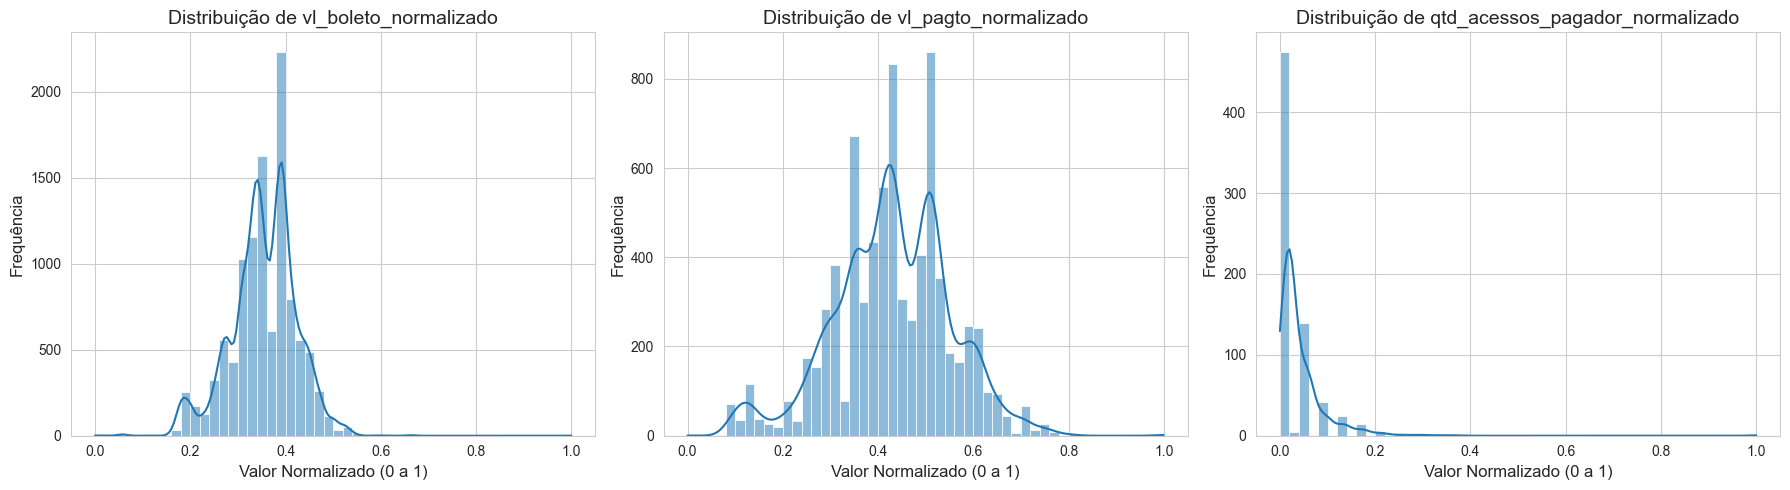

In [ ]:
# Histogramas das trêsvariáveis normalizadas

# 1 º Passo: Importação das bibliotecas necessárias:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# importa o escalonador Min-Max da biblioteca scikit-learn
from sklearn.preprocessing import MinMaxScaler

# 2 º Passo: Carregamento e pré-processamento dos dados:
print("Iniciando o carregamento e pré-processamento dos dados:")
file_path = "../dados/Grupo com vencimento 07-12 2024 - GF.csv"

try:
    # leitura do arquivo CSV, especificando o separador de colunas como tabulação ('\t').
    df = pd.read_csv(file_path, sep='\t')

    # substituição do marcador de nulo '\\N' por np.nan.
    df.replace('\\N', np.nan, inplace=True)

    # seleção das colunas de interesse.
    colunas_interesse = ['vl_boleto', 'vl_pagto', 'qtd_acessos_pagador']
    df_analise = df[colunas_interesse].copy()

    # itera sobre as colunas para garantir que todas sejam do tipo numérico.
    for col in colunas_interesse:
        df_analise[col] = pd.to_numeric(df_analise[col], errors='coerce')
    
    print("Dados carregados e limpos.")
    
    # 3 º Passo: Escalonamento das variáveis (Normalização):
    print("Aplicando a Normalização (Min-Max Scaling):")
    
    # cria um novo DataFrame para armazenar os dados escalonados
    df_scaled = pd.DataFrame()
    
    # itera sobre cada coluna para aplicar o escalonamento individualmente
    for col in colunas_interesse:
        # instancia um novo escalonador para cada coluna
        scaler = MinMaxScaler()
        
        # o escalonador espera um formato 2D, por isso usamos .values.reshape(-1, 1)
        # o .dropna() aqui garante que o escalonador seja treinado apenas com valores válidos
        scaled_column = scaler.fit_transform(df_analise[[col]].dropna())
        
        # cria uma série temporária para realinhar os dados escalonados com os índices originais
        temp_series = pd.Series(scaled_column.flatten(), index=df_analise[col].dropna().index)
        
        # adiciona a coluna escalonada ao novo DataFrame
        df_scaled[f"{col}_normalizado"] = temp_series

    print("Dados escalonados.")

    # 4 º Passo: Geração e salvamento dos histogramas
    # ------------------------------------------------------------------------------
    print("Gerando os histogramas das variáveis normalizadas:")
    
    # configura o estilo dos gráficos
    sns.set_style("whitegrid")
    
    # cria uma figura e um conjunto de subplots (1 linha, 3 colunas)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Itera sobre as colunas do DataFrame ESCALONADO para criar os gráficos
    for i, col in enumerate(df_scaled.columns):
        # Cria o histograma no eixo correspondente (axes[i])
        sns.histplot(df_scaled[col].dropna(), kde=True, bins=50, ax=axes[i])
        axes[i].set_title(f'Distribuição de {col}', fontsize=14)
        axes[i].set_xlabel('Valor Normalizado (0 a 1)', fontsize=12)
        axes[i].set_ylabel('Frequência', fontsize=12)
        
    # ajusta o layout para evitar sobreposição de títulos
    plt.tight_layout()
    
    # salva a figura em um arquivo de imagem
    plt.savefig('../assets/histogramas_normalizados.png')
    
    print("Histogramas salvos com sucesso no arquivo 'histogramas_normalizados.png'")

except FileNotFoundError:
    print(f"ERRO: O arquivo não foi encontrado no caminho especificado: '{file_path}'")
except Exception as e:
    print(f"Ocorreu um erro inesperado durante a execução: {e}")

## 2.5. Verificação amostral dos Dados Originais e Normalizados

### Introdução
Após a definição da metodologia, a extração de parâmetros, a formulação de equações e a validação visual agregada por meio de histogramas, esta subseção final do processo de escalonamento se dedica a uma verificação em nível granular. O objetivo é apresentar uma comparação de uma amostra de dados antes e depois da aplicação da **Normalização Min-Max**.  

Enquanto as análises anteriores forneceram uma compreensão teórica e uma visão macroscópica da transformação, a inspeção de registros individuais serve como a prova final do impacto da operação como presente na literatura (PROVOST; FAWCETT, 2013).  

Esta etapa é análoga a um teste de unidade no ciclo de desenvolvimento de software: ela verifica se a lógica de transformação, que foi projetada e analisada em teoria, funciona precisamente como esperado em instâncias de dados reais.  

Serão apresentadas duas tabelas contendo os dez primeiros registros das variáveis quantitativas em seu estado original e em seu estado já normalizado.

---

### Desenvolvimento e Metodologia da Amostragem
A metodologia para esta verificação final foi feita utilizando a biblioteca **pandas**, onde foram geradas duas visualizações tabulares a partir de dois DataFrames distintos:  

- **df_analise** → contendo os dados limpos, mas em sua escala original.  
- **df_scaled** → armazenando os resultados da aplicação do **MinMaxScaler** do scikit-learn.  

Para extrair a amostra representativa dos primeiros registros de cada conjunto de dados, foi empregado o método **`.head(10)`**, uma função padrão do pandas para a inspeção inicial de dados.  

Esta abordagem simples e eficaz permite um comparativo direto, pois preserva a correspondência de índices entre as duas tabelas, possibilitando a análise do efeito da transformação em cada linha individualmente.

---

### Resultados e Comparação Tabular Detalhada
A execução do processo resultou nas duas tabelas a seguir. A primeira exibe os dados em sua escala original, caracterizada por magnitudes e intervalos diferentes. A segunda apresenta os mesmos registros após a transformação, agora confinados ao intervalo uniforme de **[0, 1]**.

#### Tabela: Amostra dos 10 Primeiros Registros dos Dados Originais

| Índice | vl_boleto | vl_pagto | qtd_acessos_pagador |
|--------|-----------|----------|----------------------|
| 0 | 240.65 | 223.80 | NaN |
| 1 | 155.33 | 158.54 | NaN |
| 2 | 325.52 | 302.73 | 1.0 |
| 3 | 325.52 | 302.73 | NaN |
| 4 | 290.97 | 290.97 | NaN |
| 5 | 244.14 | 227.05 | 2.0 |
| 6 | 155.36 | 144.48 | NaN |
| 7 | 194.21 | 180.62 | 1.0 |
| 8 | 155.36 | 144.48 | 3.0 |
| 9 | 155.36 | 144.48 | 2.0 |

---

#### Tabela: Amostra dos 10 Primeiros Registros dos Dados Normalizados

| Índice | vl_boleto_normalizado | vl_pagto_normalizado | qtd_acessos_pagador_normalizado |
|--------|------------------------|-----------------------|---------------------------------|
| 0 | 0.28 | 0.26 | NaN |
| 1 | 0.18 | 0.13 | NaN |
| 2 | 0.38 | 0.43 | 0.00 |
| 3 | 0.38 | 0.43 | NaN |
| 4 | 0.34 | 0.41 | NaN |
| 5 | 0.29 | 0.27 | 0.02 |
| 6 | 0.18 | 0.10 | NaN |
| 7 | 0.23 | 0.17 | 0.00 |
| 8 | 0.18 | 0.10 | 0.04 |
| 9 | 0.18 | 0.10 | 0.02 |

---

### Análise Comparativa em Nível de Registro
A comparação direta entre as tabelas permite uma **verificação matemática da transformação**.  

Tomemos como exemplo o registro de **índice 2**:

#### Normalização das Variáveis

- **vl_boleto**:  
O valor original é `325.52`.  
Utilizando a equação de normalização derivada na subseção **2.3** para esta variável:

$$
vl_{boleto}^{norm} = \frac{vl_{boleto} - 1.0}{854.62 - 1.0}
$$

Aplicando o cálculo:

$$
\frac{325.52 - 1.0}{854.62 - 1.0} = \frac{324.52}{853.62} \approx 0.3802
$$

Esse valor, arredondado para **duas casas decimais**, é:

$$
vl_{boleto}^{norm} = 0.38
$$

---

- **vl_pagto**:  

O valor original de *vl_pagto* é `302.73`.  
Aplicando a equação de normalização:

$$
vl_{pagto}^{norm} = \frac{vl_{pagto} - 99.0}{566.83 - 99.0}
$$

Substituindo:

$$
\frac{302.73 - 99.0}{566.83 - 99.0} = \frac{203.73}{467.83} \approx 0.4355
$$

Arredondando para duas casas decimais:

$$
vl_{pagto}^{norm} = 0.44
$$

---

- **qtd_acessos_pagador**:  
O valor original é `1.0`.  
Utilizando a equação correspondente:

$$
qtd_{acessos\_pagador}^{norm} = \frac{qtd_{acessos\_pagador} - 1.0}{53.0 - 1.0}
$$

O cálculo é:

$$
\frac{1.0 - 1.0}{53.0 - 1.0} = \frac{0.0}{52.0} = 0.00
$$

Resultado final:

$$
qtd_{acessos\_pagador}^{norm} = 0.00
$$

---

Ademais, é fundamental observar o **tratamento dos valores ausentes**.  
No registro de **índice 0**, a variável *qtd_acessos_pagador* possui um valor `NaN` (*Not a Number*).  

Na Tabela com os dados normalizados, este valor é corretamente preservado como `NaN`.  
Isso demonstra que o processo de escalonamento foi aplicado de forma correta, mantendo a integridade dos dados faltantes, que deverão ser tratados em uma etapa posterior, se for necessário.

---

### Conclusão
A apresentação e a análise comparativa das tabelas de dados originais e escalonados forneceram a validação final de todo o processo de Normalização.  

Foi demonstrado, por meio de cálculos explícitos em registros amostrais, que a transformação foi implementada com precisão, convertendo as escalas díspares das variáveis para um intervalo uniforme de **[0, 1]**, de acordo com as regras matemáticas previamente estabelecidas.  

Esta verificação em nível de registro confirma a **eficácia do código implementado** e a **correção teórica da abordagem**.  

Com esta etapa, conclui-se o sub-processo de escalonamento de dados do projeto, resultando em um conjunto de dados cujas variáveis quantitativas estão agora **preparadas, consistentes e otimizadas** para serem utilizadas nos algoritmos de aprendizado de máquina que constituem o núcleo deste projeto de modelo preditivo para a **Finnet**.


In [ ]:
# Tabelas com os 10 primeiros registros dos dados originais e normalizados

# 1 º Passo: Importação das bibliotecas necessárias:
import pandas as pd
import numpy as np
# importa o escalonador Min-Max da biblioteca scikit-learn
from sklearn.preprocessing import MinMaxScaler

# 2 º Passo: Carregamento e pré-processamento dos dados:
print("Iniciando o carregamento e pré-processamento dos dados:")

# define o caminho do arquivo de dados
file_path = "../dados/Grupo com vencimento 07-12 2024 - GF.csv"

try:
    # leitura do arquivo CSV, especificando o separador de colunas como tabulação ('\t')
    df = pd.read_csv(file_path, sep='\t')

    # substituição do marcador de nulo '\\N' por np.nan
    df.replace('\\N', np.nan, inplace=True)

    # seleção das colunas de interesse.
    colunas_interesse = ['vl_boleto', 'vl_pagto', 'qtd_acessos_pagador']
    df_analise = df[colunas_interesse].copy()

    # itera sobre as colunas para garantir que todas sejam do tipo numérico
    for col in colunas_interesse:
        df_analise[col] = pd.to_numeric(df_analise[col], errors='coerce')
    
    print("Dados carregados e limpos.")
    
    # 3 º Passo: Exibição da tabela de dados originais
    print("\n--- Tabela 1: 10 Primeiros Registros dos Dados Originais ---\n")
    # usamos .head(10) para selecionar os 10 primeiros registros
    display(df_analise.head(10))
    
    # 4 º Passo: Escalonamento com MinMaxScaler e exibição da tabela:
    print("\n--- Tabela 2: 10 Primeiros Registros dos Dados Normalizados (Escalonados) ---\n")
    
    # cria um novo DataFrame para armazenar os dados escalonados
    df_scaled = pd.DataFrame()
    
    # itera sobre cada coluna para aplicar o escalonamento individualmente
    for col in colunas_interesse:
        # instancia um novo escalonador para cada coluna
        scaler = MinMaxScaler()
        
        # o escalonador não lida com NaNs, então aplicamos .dropna() na coluna antes de escalar
        # o escalonador espera um formato 2D, por isso usamos df_analise[[col]]
        scaled_column = scaler.fit_transform(df_analise[[col]].dropna())
        
        #cria uma série temporária para realinhar os dados escalonados com os índices originais
        temp_series = pd.Series(scaled_column.flatten(), index=df_analise[col].dropna().index)
        
        # adiciona a coluna escalonada ao novo DataFrame
        df_scaled[f'{col}_normalizado'] = temp_series

    # exibe os 10 primeiros registros do DataFrame escalonado, arredondando para 6 casas decimais
    display(df_scaled.head(10).round(6))

except FileNotFoundError:
    print(f"ERRO: O arquivo não foi encontrado no caminho especificado: '{file_path}'")
except Exception as e:
    print(f"Ocorreu um erro inesperado durante a execução: {e}")

Iniciando o carregamento e pré-processamento dos dados:
Dados carregados e limpos.

--- Tabela 1: 10 Primeiros Registros dos Dados Originais ---



,vl_boleto,vl_pagto,qtd_acessos_pagador
0,240.65,223.80,NaN
1,155.33,158.54,NaN
2,325.52,302.73,2.0
3,325.52,302.73,NaN
4,290.97,290.97,NaN
5,244.14,227.05,8.0
6,155.36,144.48,NaN
7,194.21,180.62,NaN
8,155.36,144.48,NaN
9,155.36,144.48,NaN



--- Tabela 2: 10 Primeiros Registros dos Dados Normalizados (Escalonados) ---



,vl_boleto_normalizado,vl_pagto_normalizado,qtd_acessos_pagador_normalizado
0,0.280746,0.266764,NaN
1,0.180795,0.127268,NaN
2,0.380169,0.435479,0.019231
3,0.380169,0.435479,NaN
4,0.339694,0.410341,NaN
5,0.284834,0.273711,0.134615
6,0.180830,0.097215,NaN
7,0.226342,0.174465,NaN
8,0.180830,0.097215,NaN
9,0.180830,0.097215,NaN
